# Atividade Prática III — Métodos Numéricos

**Alunos:** Guilherme Bento Ramos — 185226; Breno Porto Pinheiro do Prado — 185196.

Implementação dos métodos da **bisseção**, de **Newton** e da **secante** para aproximação de raízes. Este notebook é compatível com Google Colab e pode ser executado integralmente, de cima para baixo.

Os GIFs são gerados no diretório de trabalho atual. No Colab, execute a célula de animações e faça o download dos arquivos produzidos, se necessário.

## Critério de parada e tratamento de falhas

Usa-se `tol = 1e-6` e `max_iter = 100` como valores padrão. O único critério de convergência é o **resíduo** `|f(x)| < tol`: um passo pequeno, sozinho, não declara convergência. A bisseção mantém e reduz continuamente um intervalo que contém a raiz.

As funções retornam um dicionário com `aproximacao`, `iteracoes`, `historico`, `convergiu` e `resultado`. São detectados: intervalo sem mudança de sinal, derivada próxima de zero, denominador próximo de zero, avaliações não finitas e máximo de iterações.

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import FileLink, Image, display
except ImportError:  # permite executar as células também como Python comum
    class FileLink:
        def __init__(self, filename): self.filename = filename
        def __repr__(self): return self.filename
    class Image:
        def __init__(self, filename): self.filename = filename
        def __repr__(self): return self.filename
    def display(obj): print(obj)
from matplotlib import animation

TOL = 1e-6
MAX_ITER = 100
EPS = 1e-14  # limiar numérico para divisões inseguras


In [2]:
def _resultado(aproximacao, iteracoes, historico, convergiu, resultado):
    """Padroniza o retorno dos três métodos."""
    return {
        'aproximacao': aproximacao,
        'iteracoes': iteracoes,
        'historico': historico,
        'convergiu': convergiu,
        'resultado': resultado,
    }


def _valor_finito(valor):
    return math.isfinite(float(valor))


def bissecao(f, a, b, tol=1e-6, max_iter=100):
    """Encontra uma raiz em [a, b] por bisseção, quando há mudança de sinal."""
    historico = []
    if tol <= 0 or max_iter <= 0 or a >= b:
        return _resultado(None, 0, historico, False, 'falha: parâmetros inválidos')
    try:
        fa, fb = float(f(a)), float(f(b))
    except Exception as erro:
        return _resultado(None, 0, historico, False, f'falha ao avaliar f: {erro}')
    if not (_valor_finito(fa) and _valor_finito(fb)):
        return _resultado(None, 0, historico, False, 'falha: valor não finito')
    if abs(fa) < tol:
        return _resultado(a, 0, historico, True, 'convergiu: extremo esquerdo')
    if abs(fb) < tol:
        return _resultado(b, 0, historico, True, 'convergiu: extremo direito')
    if fa * fb > 0:
        return _resultado(None, 0, historico, False, 'falha: f(a)f(b) > 0')

    for k in range(1, max_iter + 1):
        x = (a + b) / 2
        try:
            fx = float(f(x))
        except Exception as erro:
            return _resultado(x, k - 1, historico, False, f'falha ao avaliar f: {erro}')
        if not _valor_finito(fx):
            return _resultado(x, k - 1, historico, False, 'falha: valor não finito')
        if fa * fx <= 0:
            b, fb = x, fx
        else:
            a, fa = x, fx
        historico.append({'iteracao': k, 'x': x, 'fx': fx, 'a': a, 'b': b})
        if abs(fx) < tol:
            return _resultado(x, k, historico, True, 'convergiu')
    return _resultado(x, max_iter, historico, False, 'falha: máximo de iterações')


def newton(f, df, x0, tol=1e-6, max_iter=100):
    """Encontra uma raiz pelo método de Newton usando f e sua derivada df."""
    historico = []
    if tol <= 0 or max_iter <= 0:
        return _resultado(None, 0, historico, False, 'falha: parâmetros inválidos')
    x = float(x0)
    for k in range(1, max_iter + 1):
        try:
            fx, dfx = float(f(x)), float(df(x))
        except Exception as erro:
            return _resultado(x, k - 1, historico, False, f'falha ao avaliar função: {erro}')
        if not (_valor_finito(fx) and _valor_finito(dfx)):
            return _resultado(x, k - 1, historico, False, 'falha: valor não finito')
        if abs(fx) < tol:
            return _resultado(x, k - 1, historico, True, 'convergiu: resíduo inicial')
        if abs(dfx) < EPS:
            return _resultado(x, k - 1, historico, False, 'falha: derivada próxima de zero')
        proximo = x - fx / dfx
        if not _valor_finito(proximo):
            return _resultado(x, k - 1, historico, False, 'falha: aproximação não finita')
        f_proximo = float(f(proximo))
        historico.append({'iteracao': k, 'x': proximo, 'fx': f_proximo,
                          'x_anterior': x, 'fx_anterior': fx, 'dfx': dfx})
        if abs(f_proximo) < tol:
            return _resultado(proximo, k, historico, True, 'convergiu')
        x = proximo
    return _resultado(x, max_iter, historico, False, 'falha: máximo de iterações')


def secante(f, x0, x1, tol=1e-6, max_iter=100):
    """Encontra uma raiz pelo método da secante a partir de x0 e x1."""
    historico = []
    if tol <= 0 or max_iter <= 0:
        return _resultado(None, 0, historico, False, 'falha: parâmetros inválidos')
    x_anterior, x = float(x0), float(x1)
    try:
        f_anterior, fx = float(f(x_anterior)), float(f(x))
    except Exception as erro:
        return _resultado(None, 0, historico, False, f'falha ao avaliar f: {erro}')
    if not (_valor_finito(f_anterior) and _valor_finito(fx)):
        return _resultado(None, 0, historico, False, 'falha: valor não finito')
    if abs(f_anterior) < tol:
        return _resultado(x_anterior, 0, historico, True, 'convergiu: x0')
    if abs(fx) < tol:
        return _resultado(x, 0, historico, True, 'convergiu: x1')

    for k in range(1, max_iter + 1):
        denominador = fx - f_anterior
        if abs(denominador) < EPS:
            return _resultado(x, k - 1, historico, False, 'falha: denominador próximo de zero')
        proximo = x - fx * (x - x_anterior) / denominador
        if not _valor_finito(proximo):
            return _resultado(x, k - 1, historico, False, 'falha: aproximação não finita')
        f_proximo = float(f(proximo))
        historico.append({'iteracao': k, 'x': proximo, 'fx': f_proximo,
                          'x0': x_anterior, 'fx0': f_anterior, 'x1': x, 'fx1': fx})
        if abs(f_proximo) < tol:
            return _resultado(proximo, k, historico, True, 'convergiu')
        x_anterior, f_anterior, x, fx = x, fx, proximo, f_proximo
    return _resultado(x, max_iter, historico, False, 'falha: máximo de iterações')


## Funções e valores iniciais sugeridos

São usados exatamente os valores sugeridos no enunciado. As derivadas foram definidas explicitamente para Newton.

In [3]:
def f1(x): return x**2 - 2
def df1(x): return 2*x

def f2(x): return x**3 - x - 2
def df2(x): return 3*x**2 - 1

def f3(x): return math.exp(-x) - x
def df3(x): return -math.exp(-x) - 1

def f4(x): return x**3 - 2*x + 2
def df4(x): return 3*x**2 - 2

problemas = [
    ('f1(x) = x² − 2', f1, df1, (1, 2), 1.5, (1, 2)),
    ('f2(x) = x³ − x − 2', f2, df2, (1, 2), 1.5, (1, 2)),
    ('f3(x) = exp(−x) − x', f3, df3, (0, 1), 0.5, (0, 1)),
    ('f4(x) = x³ − 2x + 2', f4, df4, (-2, -1), -2.0, (-2, -1)),
]


In [4]:
# Execução das 12 combinações: 4 funções × 3 métodos.
execucoes = {}
linhas = []
for nome, f, df, intervalo, x0, par_secante in problemas:
    testes = [
        ('Bisseção', f'[{intervalo[0]}, {intervalo[1]}]', bissecao(f, *intervalo, TOL, MAX_ITER)),
        ('Newton', str(x0), newton(f, df, x0, TOL, MAX_ITER)),
        ('Secante', f'({par_secante[0]}, {par_secante[1]})', secante(f, *par_secante, TOL, MAX_ITER)),
    ]
    for metodo, iniciais, retorno in testes:
        execucoes[(nome, metodo)] = retorno
        raiz = retorno['aproximacao']
        residuo = abs(f(raiz)) if raiz is not None else float('nan')
        linhas.append({
            'Função': nome,
            'Método': metodo,
            'Valores iniciais': iniciais,
            'Raiz aproximada': f'{raiz:.10f}' if raiz is not None else '—',
            '|f(x)| final': f'{residuo:.3e}' if math.isfinite(residuo) else '—',
            'Iterações/resultado': f"{retorno['iteracoes']} — {retorno['resultado']}",
        })

tabela = pd.DataFrame(linhas, columns=[
    'Função', 'Método', 'Valores iniciais', 'Raiz aproximada',
    '|f(x)| final', 'Iterações/resultado'
])
display(tabela)


,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x² − 2,Bisseção,"[1, 2]",1.4142136574,2.687e-07,21 — convergiu
1,f1(x) = x² − 2,Newton,1.5,1.4142135624,4.511e-12,3 — convergiu
2,f1(x) = x² − 2,Secante,"(1, 2)",1.4142135621,8.931e-10,5 — convergiu
3,f2(x) = x³ − x − 2,Bisseção,"[1, 2]",1.5213797092,1.450e-08,22 — convergiu
4,f2(x) = x³ − x − 2,Newton,1.5,1.5213798060,5.894e-07,2 — convergiu
5,f2(x) = x³ − x − 2,Secante,"(1, 2)",1.5213797080,7.015e-09,6 — convergiu
6,f3(x) = exp(−x) − x,Bisseção,"[0, 1]",0.5671434402,2.348e-07,20 — convergiu
7,f3(x) = exp(−x) − x,Newton,0.5,0.5671431650,1.965e-07,2 — convergiu
8,f3(x) = exp(−x) − x,Secante,"(0, 1)",0.5671433066,2.538e-08,4 — convergiu
9,f4(x) = x³ − 2x + 2,Bisseção,"[-2, -1]",-1.7692923546,2.551e-09,21 — convergiu


## Análise comparativa

Com os valores sugeridos, as 12 combinações convergem. A bisseção é previsível por manter um intervalo com mudança de sinal, mas normalmente exige mais iterações. Newton foi o mais rápido nos testes quando a derivada não ficou próxima de zero; ele depende de uma boa aproximação inicial. A secante evita calcular a derivada e, nestes casos, apresentou convergência rápida, embora possa falhar quando os valores de função geram um denominador quase nulo. As mensagens da tabela e o retorno das funções registram tais falhas caso ocorram.

## Animações didáticas

As três animações usam os históricos já calculados: bisseção em `f1`, Newton em `f2` e secante em `f3`. Cada quadro mostra a curva, o eixo `y=0`, a construção geométrica do método, iteração, aproximação e resíduo.

In [5]:
def _preparar_eixos(f, limites, titulo):
    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    xs = np.linspace(*limites, 500)
    ax.plot(xs, [f(float(x)) for x in xs], color='#1f4e79', label='f(x)')
    ax.axhline(0, color='black', linewidth=0.9)
    ax.grid(alpha=0.25)
    ax.set_xlim(*limites)
    ax.set_title(titulo)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    return fig, ax


def salvar_animacao_bissecao(f, retorno, arquivo, limites):
    historico = retorno['historico']
    fig, ax = _preparar_eixos(f, limites, 'Bisseção: f1(x) = x² − 2')
    texto = ax.text(0.02, 0.96, '', transform=ax.transAxes, va='top',
                    bbox={'facecolor': 'white', 'alpha': 0.85})
    def atualizar(i):
        item = historico[i]
        for faixa in list(ax.patches): faixa.remove()
        for linha in list(ax.lines[2:]): linha.remove()
        ax.axvspan(item['a'], item['b'], color='#8ecae6', alpha=0.35, label='intervalo atual')
        anteriores = historico[:i + 1]
        ax.plot([h['x'] for h in anteriores], [h['fx'] for h in anteriores], 'o-', color='#e76f51', ms=4, label='aproximações')
        ax.legend(loc='lower left')
        texto.set_text(f"Iteração: {item['iteracao']}\nx = {item['x']:.8f}\n|f(x)| = {abs(item['fx']):.3e}")
        return texto,
    anim = animation.FuncAnimation(fig, atualizar, frames=len(historico), interval=550, blit=False)
    anim.save(arquivo, writer=animation.PillowWriter(fps=2), dpi=100)
    plt.close(fig)


def salvar_animacao_newton(f, retorno, arquivo, limites):
    historico = retorno['historico']
    fig, ax = _preparar_eixos(f, limites, 'Newton: f2(x) = x³ − x − 2')
    texto = ax.text(0.02, 0.96, '', transform=ax.transAxes, va='top',
                    bbox={'facecolor': 'white', 'alpha': 0.85})
    def atualizar(i):
        item = historico[i]
        for linha in list(ax.lines[2:]): linha.remove()
        x_ant, fx_ant, dfx = item['x_anterior'], item['fx_anterior'], item['dfx']
        xs = np.linspace(x_ant - 0.7, x_ant + 0.7, 40)
        ax.plot(xs, fx_ant + dfx * (xs - x_ant), '--', color='#f4a261', label='tangente')
        ax.plot([x_ant], [fx_ant], 'o', color='#264653', label='ponto anterior')
        ax.plot([item['x']], [0], 'o', color='#e63946', label='novo x')
        ax.legend(loc='lower left')
        texto.set_text(f"Iteração: {item['iteracao']}\nx = {item['x']:.8f}\n|f(x)| = {abs(item['fx']):.3e}")
        return texto,
    anim = animation.FuncAnimation(fig, atualizar, frames=len(historico), interval=700, blit=False)
    anim.save(arquivo, writer=animation.PillowWriter(fps=2), dpi=100)
    plt.close(fig)


def salvar_animacao_secante(f, retorno, arquivo, limites):
    historico = retorno['historico']
    fig, ax = _preparar_eixos(f, limites, 'Secante: f3(x) = exp(−x) − x')
    texto = ax.text(0.02, 0.96, '', transform=ax.transAxes, va='top',
                    bbox={'facecolor': 'white', 'alpha': 0.85})
    def atualizar(i):
        item = historico[i]
        for linha in list(ax.lines[2:]): linha.remove()
        x0, y0, x1, y1 = item['x0'], item['fx0'], item['x1'], item['fx1']
        xs = np.linspace(min(x0, x1, item['x']) - 0.1, max(x0, x1, item['x']) + 0.1, 30)
        ys = y0 + (y1 - y0) * (xs - x0) / (x1 - x0)
        ax.plot(xs, ys, '--', color='#f4a261', label='secante')
        ax.plot([x0, x1], [y0, y1], 'o', color='#264653', label='pontos usados')
        ax.plot([item['x']], [0], 'o', color='#e63946', label='novo x')
        ax.legend(loc='upper right')
        texto.set_text(f"Iteração: {item['iteracao']}\nx = {item['x']:.8f}\n|f(x)| = {abs(item['fx']):.3e}")
        return texto,
    anim = animation.FuncAnimation(fig, atualizar, frames=len(historico), interval=700, blit=False)
    anim.save(arquivo, writer=animation.PillowWriter(fps=2), dpi=100)
    plt.close(fig)


Bisseção em f1: /home/gbntr/Desktop/calculo-numerico/animacao_bissecao_f1.gif (149.3 KiB)


/home/gbntr/Desktop/calculo-numerico/animacao_bissecao_f1.gif

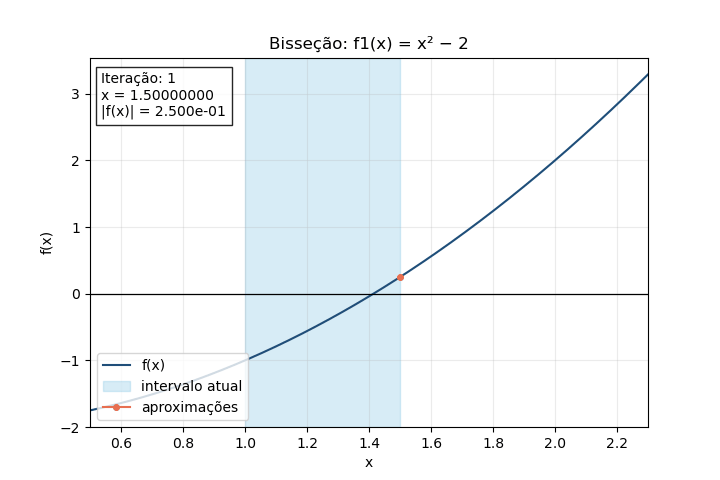

Newton em f2: /home/gbntr/Desktop/calculo-numerico/animacao_newton_f2.gif (32.1 KiB)


/home/gbntr/Desktop/calculo-numerico/animacao_newton_f2.gif

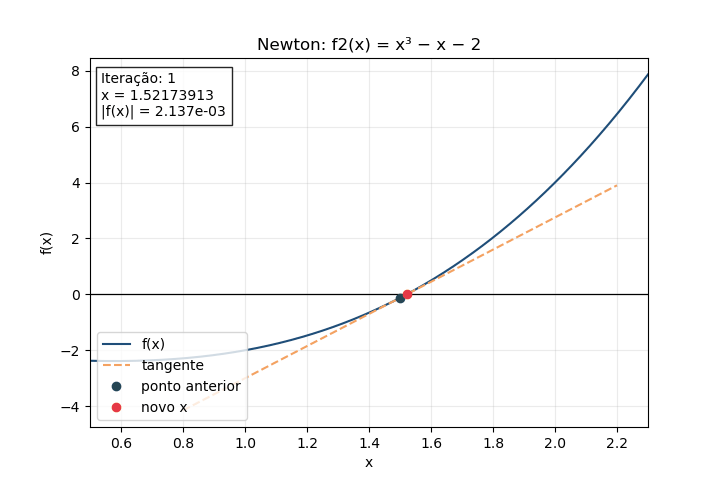

Secante em f3: /home/gbntr/Desktop/calculo-numerico/animacao_secante_f3.gif (44.9 KiB)


/home/gbntr/Desktop/calculo-numerico/animacao_secante_f3.gif

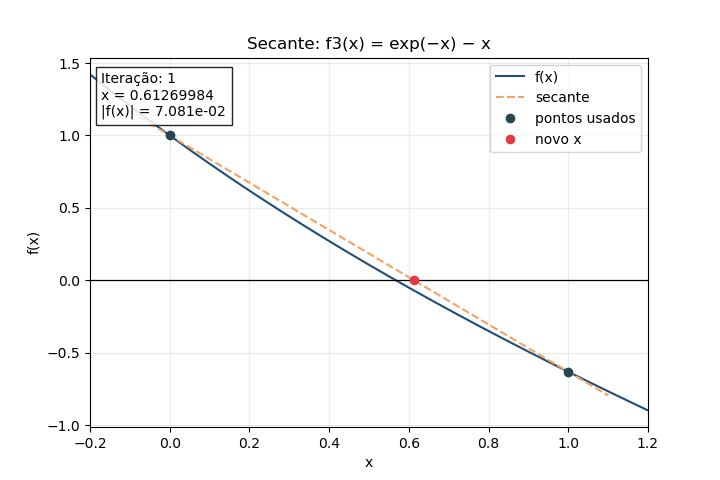

In [6]:
# Esta célula regenera os três GIFs reais no diretório atual.
arquivos_gif = {
    'Bisseção em f1': 'animacao_bissecao_f1.gif',
    'Newton em f2': 'animacao_newton_f2.gif',
    'Secante em f3': 'animacao_secante_f3.gif',
}
salvar_animacao_bissecao(f1, execucoes[('f1(x) = x² − 2', 'Bisseção')], arquivos_gif['Bisseção em f1'], (0.5, 2.3))
salvar_animacao_newton(f2, execucoes[('f2(x) = x³ − x − 2', 'Newton')], arquivos_gif['Newton em f2'], (0.5, 2.3))
salvar_animacao_secante(f3, execucoes[('f3(x) = exp(−x) − x', 'Secante')], arquivos_gif['Secante em f3'], (-0.2, 1.2))

for descricao, arquivo in arquivos_gif.items():
    caminho = Path(arquivo)
    print(f'{descricao}: {caminho.resolve()} ({caminho.stat().st_size / 1024:.1f} KiB)')
    display(FileLink(arquivo))
    display(Image(filename=arquivo))


## Entrega

Para a entrega, envie este notebook, os três GIFs gerados e a tabela de resultados. No Google Colab, use os links acima para baixar os GIFs após executar a célula correspondente.